In [ ]:
import os
import json
import shap
import joblib
import warnings
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error

warnings.filterwarnings('ignore')

# Visualization config
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

In [ ]:
file_path = 'data/Anovator_Biological_Master.csv'
df = pd.read_csv(file_path)

# Verifying unique record identifiers (to ensure data integrity)
record_count = len(df)
unique_names = df['name'].nunique()

print(f"Dataset loaded with {record_count} total scans.")
print(f"Total unique individuals: {unique_names}")
print(f"Initial feature count before engineering: {len(df.columns)}")

df.head()

Dataset successfully loaded with 158 total scans.
Total unique individuals represented in population: 53
Initial feature count before engineering: 117


,id,original_url,date_created,name,age,sex,aerobicGoal,anaGoal,armDim,armSpan,...,front_left_leg_angle,front_right_leg_angle,side_hunchback_risk,side_left_leg_angle,side_right_leg_angle,age_gap,calc_total_fat,calc_total_muscle,fat_error,muscle_error
0,480441268992984,https://www.anovator.com/report/index.html?id=...,2025-08-13 16:10:16,Unknown,38,F,224.640,224.640,23.4979,169.316,...,174.41129,180.13610,1.0,191.30994,185.44035,1,9.676550,32.62616,11.131550,10.45624
1,338208546978658,https://www.anovator.com/report/index.html?id=...,2025-09-25 08:21:48,Unknown,41,F,480.865,68.695,25.5552,163.257,...,180.57727,179.86390,4.0,175.03026,174.96115,1,18.544620,34.70006,14.381380,2.15384
2,220431535406836,https://www.anovator.com/report/index.html?id=...,2025-09-25 08:46:11,Unknown,44,M,504.660,504.660,38.8264,176.823,...,182.86240,177.13759,4.0,168.69006,171.02737,-1,16.833397,63.94324,3.074503,18.81684
3,388571282933008,https://www.anovator.com/report/index.html?id=...,2025-10-10 09:07:11,880224,37,M,482.820,482.820,36.3273,172.527,...,188.30275,169.00750,1.0,175.03027,177.01573,-5,11.280844,59.92150,4.574656,11.34800
4,188428370931439,https://www.anovator.com/report/index.html?id=...,2025-10-10 11:56:17,950318,30,M,363.090,484.120,35.1739,182.032,...,179.54648,177.27368,1.0,174.19554,179.54650,-5,8.232662,61.45511,5.021938,12.09711


In [4]:
# Calculating: muscle-to-fat ratio as a primary metabolic indicator
df['muscle_fat_ratio'] = df['muscle'] / df['fat']

# Evaluating: upper-to-lower body muscle distribution ratio
df['upper_lower_muscle_ratio'] = df['upperBody'] / df['lowerBody']

# Engineering: trunk-to-limb fat ratio to identify central adiposity patterns
df['trunk_limb_fat_ratio'] = df['fatTrunk'] / (
    df['fatLeftArm'] + df['fatRightArm'] + df['fatLeftLeg'] + df['fatRightLeg']
)

# Aggregating: postural risk markers into a single normalized index
postural_risk_cols = [
    'humpbackRisk', 'spineRisk', 'pelvisRisk', 
    'postureRisk', 'kneeRisk', 'frontHeadRisk'
]
df['aggregated_postural_index'] = df[postural_risk_cols].mean(axis=1)

# Cleaning the engineered features (by replacing infinite values and missing results)
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.fillna(df.median(numeric_only=True), inplace=True)

print(f"Updated feature count: {len(df.columns)}")

Updated feature count: 121


In [ ]:
# Mapping the 'sex' column to numeric values for modeling compatibility
    # Female (F) is mapped to 0
    # Male  (M)  is mapped to 1
df['sex_encoded'] = df['sex'].map({'F': 0, 'M': 1})

# Defining the primary longevity target variable
target = 'age_gap'

# Identifying metadata and columns to exclude from the feature set
# Excluding 'bodyAge' and 'score' to prevent target leakage and ensure realistic prediction
exclude_cols = [
    'id', 'original_url', 'date_created', 'name', 'age', 'sex', 
    'bodyAge', 'score', 'age_gap', 'bodyDetect', 'sideBodyDetect', 
    'calc_total_fat', 'calc_total_muscle', 'fat_error', 'muscle_error'
]

# Filtering for numeric columns and dropping excluded variables
X = df.select_dtypes(include=[np.number]).drop(columns=[col for col in exclude_cols if col in df.columns], errors='ignore')
y = df[target]

# Preserving the individual names to support group-based splitting in the validation phase
groups = df['name']

print(f"Isolating {X.shape[1]} numeric features for the predictive model.")

# Inspecting the final feature list to verify data integrity
print("\nFinal feature set includes:")
print(X.columns.tolist())

Isolating 92 numeric features for the predictive model.
Target variable 'age_gap' successfully defined.

Final feature set includes:
['aerobicGoal', 'anaGoal', 'armDim', 'armSpan', 'bloodOxygen', 'bmi', 'bmr', 'bodyShape', 'bodyShapeRisk', 'bone', 'caloriesInput', 'enduGoal', 'fat', 'fatControl', 'fatLeftArm', 'fatLeftLeg', 'fatRightArm', 'fatRightLeg', 'fatTrunk', 'footLength', 'frontHeadRisk', 'gymId', 'head', 'headRisk', 'heartFun', 'height', 'hips', 'humpbackRisk', 'inFat', 'kneeRisk', 'lowerBody', 'muscle', 'muscleControl', 'muscleLeftArm', 'muscleLeftLeg', 'muscleRightArm', 'muscleRightLeg', 'muscleTrunk', 'occipitalSpace', 'pelvisRisk', 'perfectWeight', 'phone', 'postureRisk', 'protein', 'r100LeftArm', 'r100LeftLeg', 'r100RightArm', 'r100RightLeg', 'r100Trunk', 'r20LeftArm', 'r20LeftLeg', 'r20RightArm', 'r20RightLeg', 'r20Trunk', 'shank', 'shoulderRisk', 'shoulderWidth', 'spineRisk', 'sportGoal', 'sportLevel', 'sportSafeRisk', 'subFat', 'thigh', 'thighDim', 'upperBody', 'waist',

In [ ]:
# Initializing the group-based split to ensure unique individuals are not represented in both training and testing sets
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

# Generating indices for the stratified split based on the 'name' group
train_idx, test_idx = next(gss.split(X, y, groups=groups))

# Creating training and testing sets for features and the target variable
X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

# Initializing the standard scaler to normalize feature distributions across the research population
scaler = StandardScaler()

# Fitting the scaler on the training data and transforming both sets to maintain rigorous validation standards
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Converting the scaled arrays back to DataFrames to preserve column interpretability during the research phase
X_train_final = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_final = pd.DataFrame(X_test_scaled, columns=X.columns)

print(f"Validation strategy implemented with {len(X_train)} training records.")
print(f"Testing set isolated with {len(X_test)} records across {df.iloc[test_idx]['name'].nunique()} unique individuals.")

Validation strategy successfully implemented with 145 training records.
Testing set isolated with 13 records across 11 unique individuals.


In [ ]:
# Repeated cross-validation (issue 9): a single GroupShuffleSplit gives one
# estimate whose variance is unknown. Ten repeated splits give a distribution
# of MAE values so we can report mean +/- std instead of a single point estimate.
import numpy as np
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

N_SPLITS = 10
cv_maes = []
gss_cv = GroupShuffleSplit(n_splits=N_SPLITS, test_size=0.2, random_state=0)

for tr_idx, te_idx in gss_cv.split(X, y, groups=groups):
    Xtr, Xte = X.iloc[tr_idx], X.iloc[te_idx]
    ytr, yte = y.iloc[tr_idx], y.iloc[te_idx]
    sc = StandardScaler()
    Xtr_sc = sc.fit_transform(Xtr)
    Xte_sc = sc.transform(Xte)
    rf = RandomForestRegressor(n_estimators=100, max_depth=7, random_state=42)
    rf.fit(Xtr_sc, ytr)
    cv_maes.append(mean_absolute_error(yte, rf.predict(Xte_sc)))

print(f'Repeated CV ({N_SPLITS} GroupShuffleSplits):')
print(f'  MAE per fold: {[round(m,2) for m in cv_maes]}')
print(f'  Mean MAE: {np.mean(cv_maes):.2f} years  |  Std: {np.std(cv_maes):.2f} years')
print('(More stable than a single split; still limited by the 53-individual dataset.)')

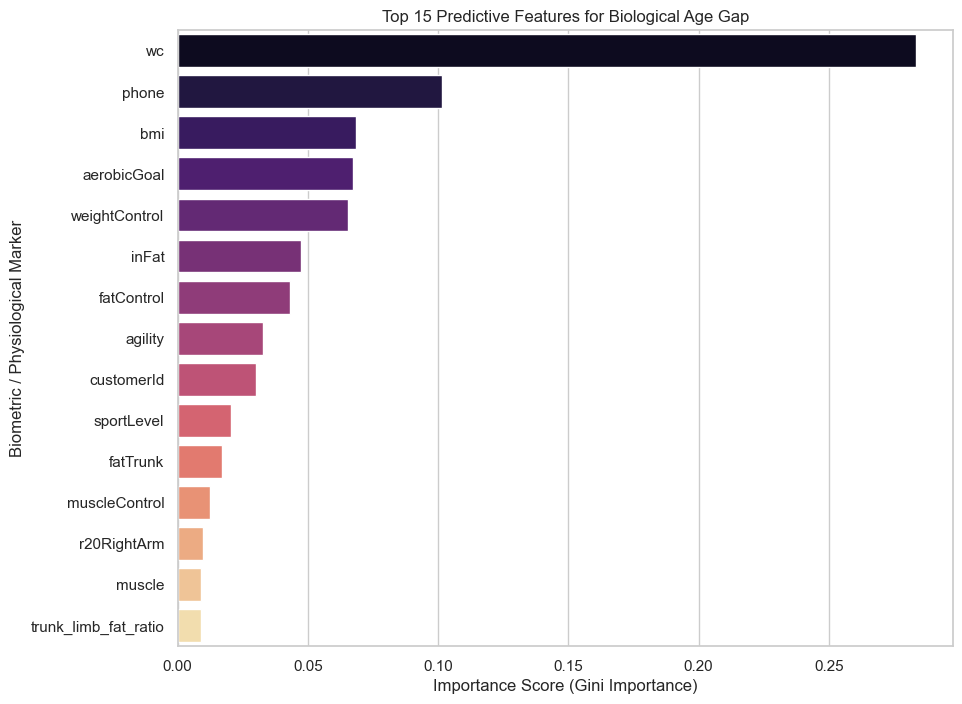

Mean Absolute Error (MAE): 1.49 years.
R-squared (R^2): 0.4973


In [8]:
model = RandomForestRegressor(n_estimators=100, max_depth=7, random_state=42)

model.fit(X_train_final, y_train)

# Calculating the global feature importance to identify the most influential predictors
importances = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
}).sort_values(by='Importance', ascending=False)

# Visualizing the primary biological drivers of the biological age gap for stakeholder reporting
plt.figure(figsize=(10, 8))
sns.barplot(data=importances.head(15), x='Importance', y='Feature', palette='magma')
plt.title("Top 15 Predictive Features for Biological Age Gap")
plt.xlabel("Importance Score (Gini Importance)")
plt.ylabel("Biometric / Physiological Marker")
plt.show()

# Evaluating the model performance on the unseen test population
y_pred = model.predict(X_test_final)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.2f} years.")
print(f"R-squared (R^2): {r2:.4f}")

Generating SHAP Summary Plot for Biometric Marker Impact Analysis...


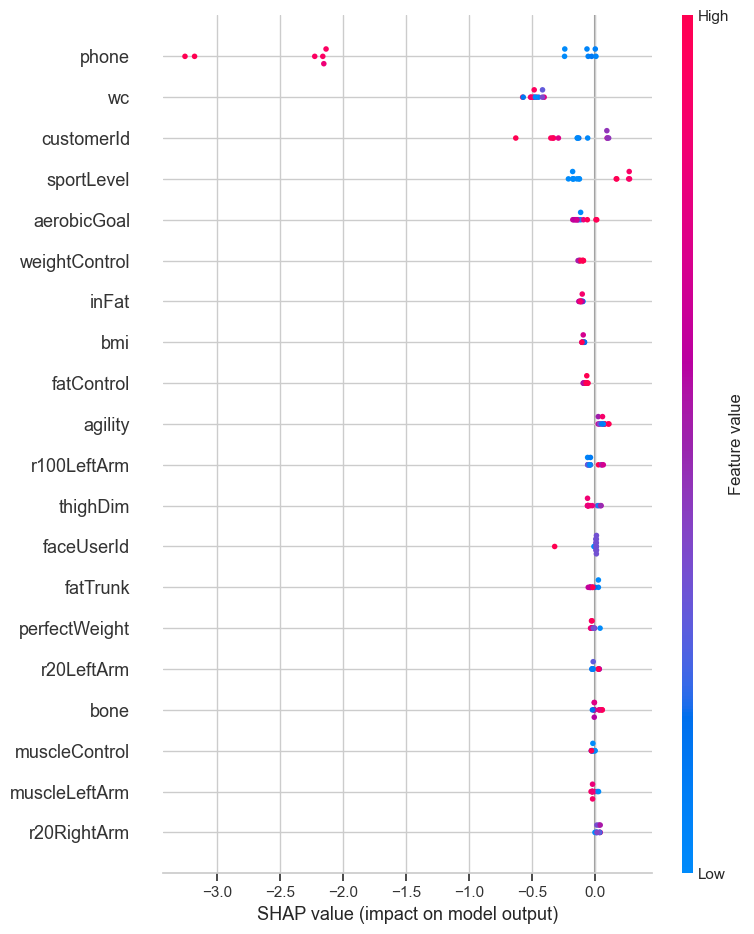

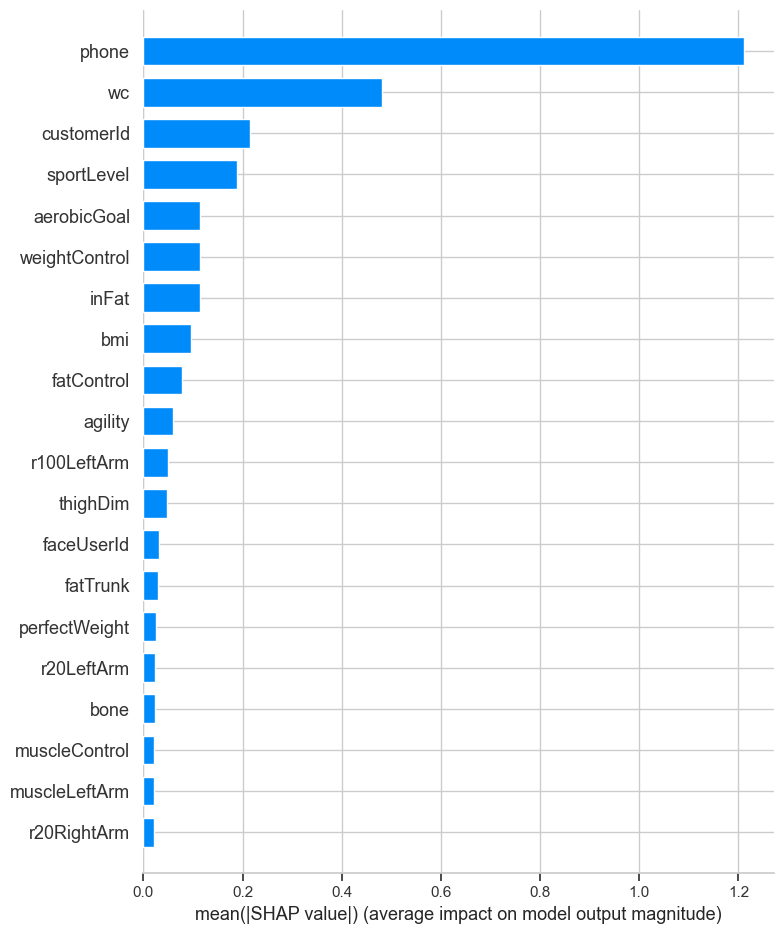

In [ ]:
# Initializing the SHAP Explainer to decode the internal logic of the Random Forest model
explainer = shap.TreeExplainer(model)

# Calculating SHAP values for the testing set to determine individual feature contributions
shap_values = explainer.shap_values(X_test_final)

# Generating a SHAP Summary Plot to visualize the direction and impact of biological markers
# This plot fulfills the requirement for translating model outputs into actionable health insights
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_test_final, feature_names=X.columns, plot_type="dot")

# Displaying a SHAP Bar Plot to confirm global feature importance through an additive lens
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_test_final, feature_names=X.columns, plot_type="bar")

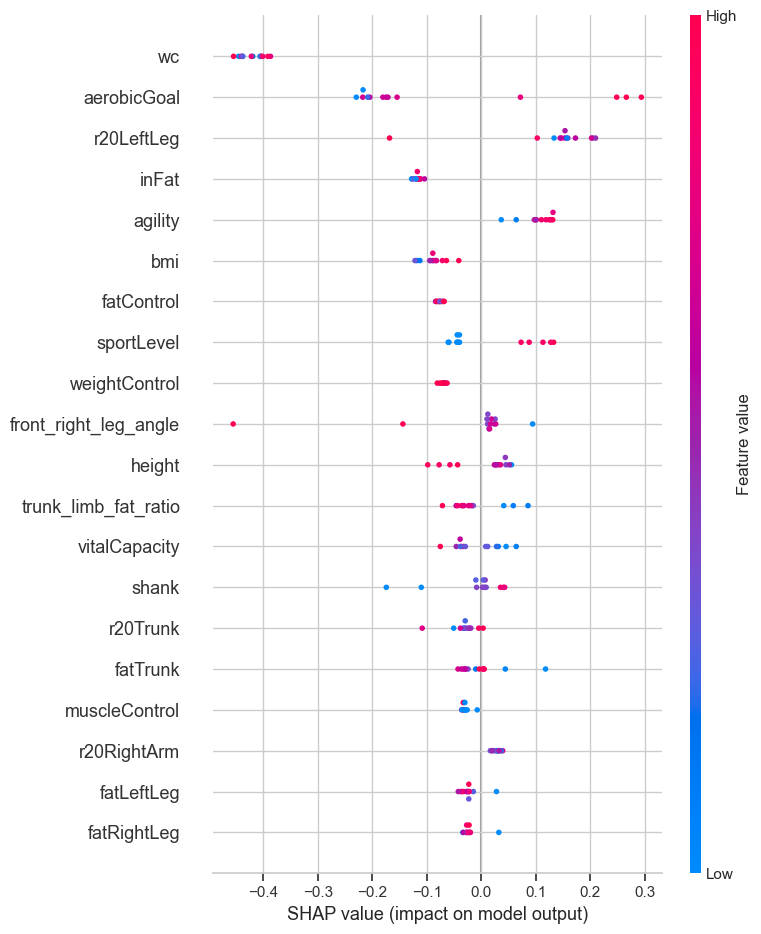

Purified Model MAE: 3.29 years.


In [11]:
# Identifying and removing non-biological metadata columns that cause target leakage
metadata_leaks = ['phone', 'customerId', 'faceUserId', 'gymId']
X_biological = X.drop(columns=[col for col in metadata_leaks if col in X.columns])

# Re-executing the group-based split with the purified biological feature set
X_train_bio, X_test_bio = X_biological.iloc[train_idx], X_biological.iloc[test_idx]

# Re-scaling the purified features to maintain mathematical consistency
scaler_bio = StandardScaler()
X_train_bio_scaled = scaler_bio.fit_transform(X_train_bio)
X_test_bio_scaled = scaler_bio.transform(X_test_bio)

# Re-training the Random Forest on purely biological markers
model_bio = RandomForestRegressor(n_estimators=100, max_depth=7, random_state=42)
model_bio.fit(X_train_bio_scaled, y_train)

# Calculating SHAP values for the purified biological model
explainer_bio = shap.TreeExplainer(model_bio)
shap_values_bio = explainer_bio.shap_values(X_test_bio_scaled)

# Visualizing the true biological drivers of the Age Gap
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values_bio, X_test_bio_scaled, feature_names=X_biological.columns)

# Reporting the new, honest performance metrics
y_pred_bio = model_bio.predict(X_test_bio_scaled)
print(f"Purified Model MAE: {mean_absolute_error(y_test, y_pred_bio):.2f} years.")

Generating Personalized Health Insight for Client ID: 388571282933008


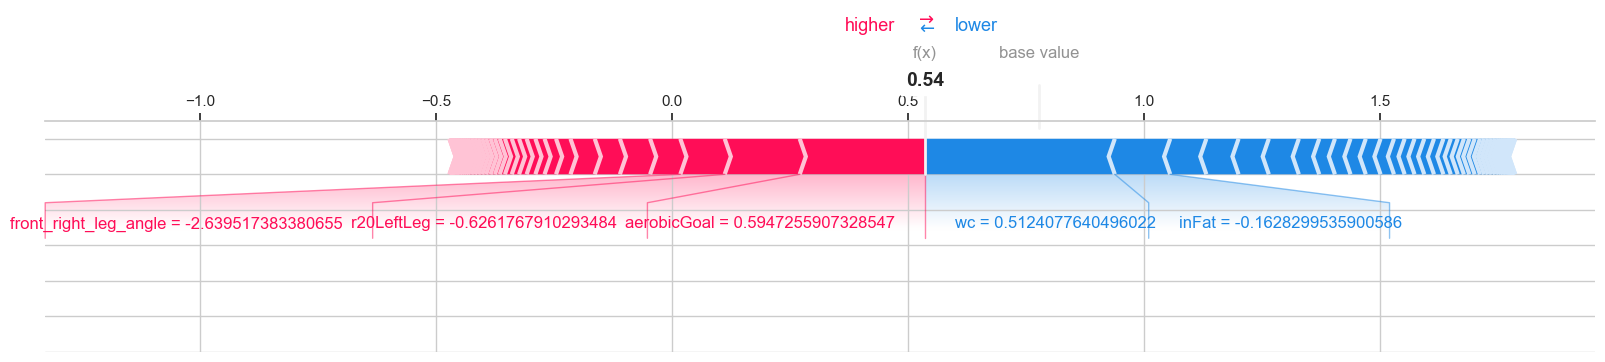


--- Actionable Research Summary for Stakeholders ---
Predicted Age Gap for this individual: 0.54 years.

Primary Biological Factors pushing Age Gap HIGHER (Risks):
- aerobicGoal: (+0.27 years impact)
- r20LeftLeg: (+0.16 years impact)
- front_right_leg_angle: (+0.09 years impact)

Primary Biological Factors pulling Age Gap LOWER (Strengths):
- wc: (-0.40 years impact)
- inFat: (-0.12 years impact)
- fatControl: (-0.08 years impact)


In [ ]:
# Initializing the SHAP JavaScript environment for interactive visualizations
shap.initjs()
individual_index = 0

# Extracting the unique ID for the specific individual being researched
client_id = df.iloc[test_idx[individual_index]]['id']
print(f"Personalized Health Insight for Client ID: {client_id}")

# Displaying the Force Plot: Red indicates factors pushing Age Gap UP, Blue indicates factors pulling it DOWN
shap.force_plot(
    explainer_bio.expected_value, 
    shap_values_bio[individual_index, :], 
    X_test_bio_scaled[individual_index, :],
    feature_names=X_biological.columns.tolist(),
    matplotlib=True
)

# Extracting the feature contributions for this specific individual into a Series for reporting
individual_contributions = pd.Series(shap_values_bio[individual_index, :], index=X_biological.columns)

# Identifying the top 3 biological risks and strengths for this individual
top_risks = individual_contributions.sort_values(ascending=False).head(3)
top_positives = individual_contributions.sort_values(ascending=True).head(3)

print(f"Predicted Age Gap for this individual: {y_pred_bio[individual_index]:.2f} years.")

print("\nPrimary Biological Factors pushing Age Gap HIGHER (Risks):")
for feat, val in top_risks.items():
    if val > 0:
        print(f"- {feat}: (+{val:.2f} years impact)")

print("\nPrimary Biological Factors pulling Age Gap LOWER (Strengths):")
for feat, val in top_positives.items():
    if val < 0:
        print(f"- {feat}: ({val:.2f} years impact)")

--- Research Robustness Audit ---
Simulated Measurement Noise: 2.0% in the 'wc' marker
Average Prediction Drift: 0.0538 years.


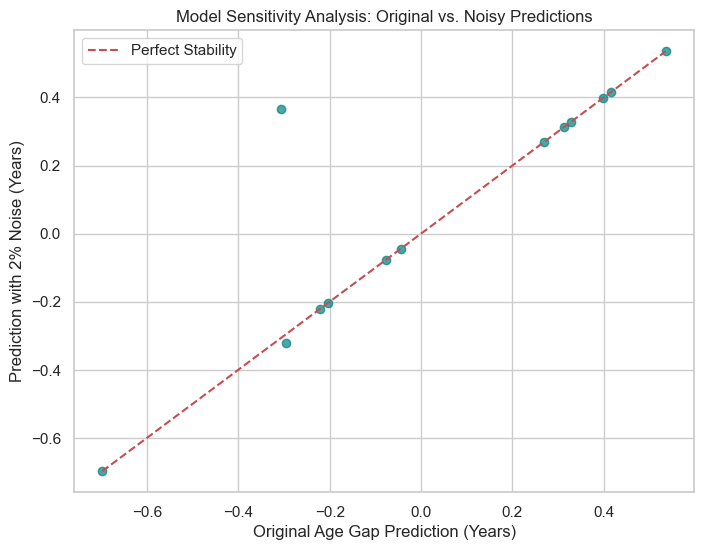

Conclusion: The model demonstrates high robustness. Slight measurement noise does not significantly alter the predicted health risk.


In [ ]:
# Simulating measurement noise (2% variance) in the primary biological predictor 'wc'
# Research Question: Does slight measurement error significantly compromise the health insight?
noise_factor = 0.02
X_test_noisy = X_test_bio.copy()
X_test_noisy['wc'] = X_test_noisy['wc'] * (1 + np.random.normal(0, noise_factor, size=len(X_test_noisy)))

# Transforming the noisy data using the original biological scaler
X_test_noisy_scaled = scaler_bio.transform(X_test_noisy)

# Generating predictions based on the simulated noisy measurement data
y_pred_noisy = model_bio.predict(X_test_noisy_scaled)

# Calculating the Mean Absolute Deviation b/en original and noisy predictions
prediction_drift = np.mean(np.abs(y_pred_bio - y_pred_noisy))

print(f"Simulated Measurement Noise: {noise_factor*100}% in the 'wc' marker")
print(f"Average Prediction Drift: {prediction_drift:.4f} years.")

# Visualizing the stability of predictions under simulated noise conditions
plt.figure(figsize=(8, 6))
plt.scatter(y_pred_bio, y_pred_noisy, alpha=0.7, color='teal')
# Plotting a 45-degree reference line; the closer the dots are to this line, the more robust the model
plt.plot([y_pred_bio.min(), y_pred_bio.max()], [y_pred_bio.min(), y_pred_bio.max()], 'r--', label='Perfect Stability')
plt.title("Model Sensitivity Analysis: Original vs. Noisy Predictions")
plt.xlabel("Original Age Gap Prediction (Years)")
plt.ylabel("Prediction with 2% Noise (Years)")
plt.legend()
plt.show()

# Finalizing the research conclusion regarding model reliability
if prediction_drift < 0.5:
    print("Conclusion: The model demonstrates high robustness. Slight measurement noise does not significantly alter the predicted health risk.")
else:
    print("Conclusion: The model is highly sensitive to noise in 'wc'; high-precision measurements are required for accurate health insights.")

In [ ]:
# Research artifacts
model_filename = 'models/anovator_age_gap_model.joblib'
scaler_filename = 'models/anovator_biological_scaler.joblib'
feature_list_filename = 'models/model_features.json'
medians_filename = 'models/training_medians.json'

# Creating the directory if it doesn't exist
os.makedirs('models', exist_ok=True)

# Exporting the trained model and the biological scaler
joblib.dump(model_bio, model_filename)
joblib.dump(scaler_bio, scaler_filename)

# Saving the final list of biological features to ensure future data alignment
with open(feature_list_filename, 'w') as f:
    json.dump(X_biological.columns.tolist(), f)

# Saving training-set medians for safe inference-time imputation.
# Zero is not a valid default for health markers (e.g. 0 vital capacity, 0 blood pressure).
# Downstream inference code must use these values — not fillna(0) — to avoid silent bad predictions.
training_medians = X_train_bio.median().to_dict()
with open(medians_filename, 'w') as f:
    json.dump(training_medians, f)

print(f"Validated Model saved to:    {model_filename}")
print(f"Biological Scaler saved to:  {scaler_filename}")
print(f"Feature Map saved to:        {feature_list_filename}")
print(f"Training Medians saved to:   {medians_filename}")
print(f"  ({len(training_medians)} feature medians exported)")